In [ ]:
!pip install pymfe
!pip install matplotlib
!pip install seaborn
!pip install openml



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 156.1/156.1 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 53.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.4/160.4 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.8/93.8 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 46.3 MB/s eta 0:00:00
  Created wheel for liac-arff: filename=liac_arff-2.5.0-py3-none-any.whl size=11717 sha256=8640602db9789e1b0c0c077a904443e63756fc71e8f53df35ef4d832d69435af
  Stored in directory: /root/.cache/pip/wheels/a9/ac/cf/c2919807a5c623926d217c0a18eb5b457e5c19d242c3b5963a
Successfully built liac-arff


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import openml
from time import time

from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression, Perceptron
from sklearn.neural_network import MLPClassifier

from sklearn.model_selection import cross_validate, StratifiedKFold, LeaveOneOut
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import KNNImputer
from sklearn.metrics import accuracy_score, f1_score

from pymfe.mfe import MFE

## Passo 1: Obter conjunto de datasets de treinamento

In [ ]:
# Obtendo a lista de datasets do OpenML:
all_datasets = openml.datasets.list_datasets(output_format='dataframe')
print(f"Total de datasets no OpenML: {len(all_datasets)}")

# Filtrando os datasets com base nos critérios especificados:

filtered_datasets = all_datasets[
    (all_datasets['NumberOfInstances'] >= 200) &
    (all_datasets['NumberOfInstances'] <= 10000) &
    (all_datasets['NumberOfFeatures'] >= 2) &
    (all_datasets['NumberOfFeatures'] <= 50) &
    (all_datasets['NumberOfClasses'] >= 2) &
    (all_datasets['NumberOfClasses'] <= 6) &
    (all_datasets['NumberOfInstancesWithMissingValues'] < all_datasets['NumberOfInstances'] * 0.3) &
    (all_datasets['MinorityClassSize'] >= 20) &
    (all_datasets['NumberOfNumericFeatures'] == all_datasets['NumberOfFeatures'] - 1) &
    (all_datasets['NumberOfInstances'] * all_datasets['NumberOfFeatures'] <= 60000)
].drop_duplicates(subset='name').reset_index(drop=True)

print(f"Quantidade de datasets após filtro: {len(filtered_datasets)}")

# Removendo datasets da mesma família (baseado no nome):
filtered_datasets['family'] = filtered_datasets['name'].str.extract(r'([a-zA-Z]+)')[0]
final_datasets = filtered_datasets.drop_duplicates(subset='family').reset_index(drop=True)
# Drop FOREX datasets:
final_datasets = final_datasets[~final_datasets['name'].str.contains('FOREX', case=False)].reset_index(drop=True)
print(f"Quantidade de datasets após remoção de famílias: {len(final_datasets)}")
# print("Datasets selecionados:")
# print(final_datasets[['name', 'NumberOfInstances', 'NumberOfFeatures', 'NumberOfClasses']])

Total de datasets no OpenML: 6408
Quantidade de datasets após filtro: 329
Quantidade de datasets após remoção de famílias: 94


In [ ]:
# Baixando os datasets filtrados:

datasets = {}   # {nome: {'data': X, 'target': y}}
failed = []

for i, row in final_datasets.iterrows():
    did = int(row['did'])
    name = row['name']

    try:
        ds = openml.datasets.get_dataset(did, download_data=True,
                                         download_qualities=False,
                                         download_features_meta_data=False)
        X, y, _, _ = ds.get_data(dataset_format='dataframe',
                                 target=ds.default_target_attribute)

        unique_name = f"{name}_did{did}" # No caso de haver versões duplicadas

        datasets[unique_name] = {'data': X, 'target': y}
        print(f"[Sucesso]: {i}: {unique_name}  ({X.shape[0]}×{X.shape[1]})")

    except Exception as e:
        failed.append(name)
        print(f"[Erro]: {i}: {name}: {e}")

print("\nDownload concluído!")
print(f"Datasets carregados com sucesso: {len(datasets)}")
print(f"Número de falhas: {len(failed)}")

[Sucesso]: 0: balance-scale_did11  (625×4)
[Sucesso]: 1: breast-w_did15  (699×9)
[Sucesso]: 2: diabetes_did37  (768×8)
[Sucesso]: 3: heart-statlog_did53  (270×13)
[Sucesso]: 4: vehicle_did54  (846×18)
[Sucesso]: 5: ionosphere_did59  (351×34)
[Sucesso]: 6: oil_spill_did311  (937×49)
[Sucesso]: 7: SPECTF_did337  (349×44)
[Sucesso]: 8: prnn_synth_did464  (250×2)
[Sucesso]: 9: rmftsa_sleepdata_did679  (1024×2)
[Sucesso]: 10: fri_c3_1000_25_did715  (1000×25)
[Sucesso]: 11: pwLinear_did721  (200×10)
[Sucesso]: 12: analcatdata_supreme_did728  (4052×7)
[Sucesso]: 13: machine_cpu_did733  (209×6)
[Sucesso]: 14: space_ga_did737  (3107×6)
[Sucesso]: 15: pm10_did750  (500×7)
[Sucesso]: 16: strikes_did770  (625×6)
[Sucesso]: 17: quake_did772  (2178×3)
[Sucesso]: 18: disclosure_x_bias_did774  (662×3)
[Sucesso]: 19: bodyfat_did778  (252×14)
[Sucesso]: 20: delta_ailerons_did803  (7129×5)
[Sucesso]: 21: chscase_vine2_did814  (468×2)
[Sucesso]: 22: chatfield_4_did820  (235×12)
[Sucesso]: 23: stock_did841

## Passo 2: Avaliar performance dos classificadores nos datasets

In [ ]:
# Define classifiers
from sklearn.impute import SimpleImputer


classifiers = {
    'DecisionTree': DecisionTreeClassifier(random_state=42),
    'SVM': SVC(random_state=42),
    'KNN': KNeighborsClassifier(),
    'LogisticRegression': LogisticRegression(random_state=42, max_iter=1000),
    'Perceptron': Perceptron(random_state=42, max_iter=1000),
    'MLP': MLPClassifier(random_state=42, max_iter=1000)
}

# Store results
results = []

# Iterate through datasets
for dataset_name, dataset in datasets.items():
    print(f'Processing dataset: {dataset_name}')

    # Get data and target
    X = dataset['data']
    y = dataset['target']

    # Handle missing values
    imputer = KNNImputer(n_neighbors=3)
    try:
        X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)
    except Exception as e:
        print(f'Warning: Imputation failed for {dataset_name} with error: {e}')
        print('Falling back to simple imputation strategy.')
        # Use most frequent strategy for string/categorical data
        imputer = SimpleImputer(missing_values=np.nan, strategy='most_frequent')
        # Fit and transform the data
        X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)


    # Handle categorical features
    for col in X.select_dtypes(include=['object']).columns:
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col].astype(str))

    # Encode target if necessary
    if y.dtype == 'object':
        le = LabelEncoder()
        y = le.fit_transform(y)

    # Evaluate each classifier
    for clf_name, clf in classifiers.items():
        print(f'  Evaluating {clf_name}...', end=' ')

        # 5-fold cross validation
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        cv_results = cross_validate(clf, X, y, cv=cv, scoring='accuracy',
                                    return_train_score=False)

        # Extract fold accuracies
        fold_accs = cv_results['test_score']

        # Create result row
        result_row = {
            'Dataset': dataset_name,
            'Classifier': clf_name,
            'acc_fold1': fold_accs[0],
            'acc_fold2': fold_accs[1],
            'acc_fold3': fold_accs[2],
            'acc_fold4': fold_accs[3],
            'acc_fold5': fold_accs[4],
            'acc_mean': fold_accs.mean(),
            'acc_stddev': fold_accs.std(),
            'train_time': cv_results['fit_time'].sum(),
            'test_time': cv_results['score_time'].sum()
        }

        results.append(result_row)
        print('Done')

# Create results DataFrame
performances_df = pd.DataFrame(results)

Processing dataset: balance-scale_did11
  Evaluating DecisionTree... Done
  Evaluating SVM... Done
  Evaluating KNN... Done
  Evaluating LogisticRegression... Done
  Evaluating Perceptron... Done
  Evaluating MLP... 

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


Done
Processing dataset: breast-w_did15
  Evaluating DecisionTree... Done
  Evaluating SVM... Done
  Evaluating KNN... Done
  Evaluating LogisticRegression... Done
  Evaluating Perceptron... Done
  Evaluating MLP... Done
Processing dataset: diabetes_did37
  Evaluating DecisionTree... Done
  Evaluating SVM... Done
  Evaluating KNN... Done
  Evaluating LogisticRegression... Done
  Evaluating Perceptron... Done
  Evaluating MLP... Done
Processing dataset: heart-statlog_did53
  Evaluating DecisionTree... Done
  Evaluating SVM... Done
  Evaluating KNN... Done
  Evaluating LogisticRegression... 

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Done
  Evaluating Perceptron... Done
  Evaluating MLP... Done
Processing dataset: vehicle_did54
  Evaluating DecisionTree... Done
  Evaluating SVM... Done
  Evaluating KNN... Done
  Evaluating LogisticRegression... 

...

Done
  Evaluating Perceptron... Done
  Evaluating MLP... Done
Processing dataset: hepatitis_c_virus_hcv_for_egyptian_patients_did46850
  Evaluating DecisionTree... Done
  Evaluating SVM... Done
  Evaluating KNN... Done
  Evaluating LogisticRegression... 

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

Done
  Evaluating Perceptron... Done
  Evaluating MLP... Done
Processing dataset: depression_2020_did46876
  Evaluating DecisionTree... Done
  Evaluating SVM... Done
  Evaluating KNN... Done
  Evaluating LogisticRegression... Done
  Evaluating Perceptron... Done
  Evaluating MLP... Done
Processing dataset: mental_health_detection_did46879
  Evaluating DecisionTree... Done
  Evaluating SVM... Done
  Evaluating KNN... Done
  Evaluating LogisticRegression... Done
  Evaluating Perceptron... Done
  Evaluating MLP... Done
Processing dataset: Pumpkin_Seeds_did46951
  Evaluating DecisionTree... Done
  Evaluating SVM... Done
  Evaluating KNN... Done
  Evaluating LogisticRegression... 

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

Done
  Evaluating Perceptron... Done
  Evaluating MLP... Done
Processing dataset: waveform_did47155
  Evaluating DecisionTree... Done
  Evaluating SVM... Done
  Evaluating KNN... Done
  Evaluating LogisticRegression... Done
  Evaluating Perceptron... Done
  Evaluating MLP... Done


In [ ]:
# Saving results to CSV
performances_df.to_csv('classifier_performances.csv', index=False)

In [ ]:
# Loading results from CSV
performances_df = pd.read_csv('classifier_performances.csv')


In [ ]:
performances_df

,Dataset,Classifier,acc_fold1,acc_fold2,acc_fold3,acc_fold4,acc_fold5,acc_mean,acc_stddev,train_time,test_time
0,balance-scale_did11,DecisionTree,0.78400,0.78400,0.73600,0.76800,0.80000,0.77440,0.021703,0.020133,0.014867
1,balance-scale_did11,SVM,0.92000,0.91200,0.88800,0.89600,0.90400,0.90400,0.011314,0.041157,0.026592
2,balance-scale_did11,KNN,0.81600,0.80000,0.81600,0.84800,0.86400,0.82880,0.023515,0.036138,0.045607
3,balance-scale_did11,LogisticRegression,0.88000,0.88800,0.88000,0.83200,0.87200,0.87040,0.019855,0.184426,0.044621
4,balance-scale_did11,Perceptron,0.88800,0.88000,0.88000,0.83200,0.87200,0.87040,0.019855,0.074680,0.029233
...,...,...,...,...,...,...,...,...,...,...,...
559,waveform_did47155,SVM,0.81250,0.80625,0.85625,0.86875,0.81875,0.83250,0.025125,0.040911,0.030260
560,waveform_did47155,KNN,0.79375,0.78750,0.80000,0.83750,0.78750,0.80125,0.018708,0.018257,0.022918
561,waveform_did47155,LogisticRegression,0.85000,0.78125,0.85000,0.88125,0.87500,0.84750,0.035488,0.163412,0.012239
562,waveform_did47155,Perceptron,0.76250,0.71875,0.79375,0.79375,0.80000,0.77375,0.030465,0.032342,0.013786


## Passo 3: Extrair meta-features dos datasets

In [ ]:
# Extract meta-features
meta_features = []

for dataset_name, dataset in list(datasets.items()):
    print(f'Extracting meta-features from {dataset_name}...', end=' ')

    # Get data and target
    X = dataset['data']
    y = dataset['target']

    # Handle categorical features
    for col in X.select_dtypes(include=['object']).columns:
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col].astype(str))

    # Handle missing values
    imputer = KNNImputer(n_neighbors=3)
    try:
        X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)
    except Exception as e:
        imputer = SimpleImputer(missing_values=np.nan, strategy='most_frequent')
        X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

    # Encode target if necessary
    if y.dtype == 'object':
        le = LabelEncoder()
        y = le.fit_transform(y)
    else:
        # Convert to numpy array if it's a pandas Series
        y = np.array(y)

    # Extract meta-features
    try:
        mfe = MFE(groups=['landmarking', 'general', 'statistical',
                           'model-based', 'info-theory', 'relative',
                            'clustering', 'complexity', 'itemset',
                            'concept'],
                           summary=['median', 'min', 'max', 'mean',
                                    'sd', 'quantiles', 'histogram'])
        # Ignore warnings during meta-feature extraction:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
        mfe.fit(X.values, y)
        ft = mfe.extract()
        # reset warnings filter to default after extraction:
        warnings.resetwarnings()

        # Create result row with dataset name and meta-features
        result_row = {'dataset': dataset_name}

        meta_features.append(pd.DataFrame(dict(zip(ft[0], ft[1])), index=[dataset_name]))
        print('Done')
    except Exception as e:
        print(f'Error: {e}')

# Create meta-features DataFrame
meta_features_df = pd.concat(meta_features, ignore_index=False)

Extracting meta-features from balance-scale_did11... 

/usr/local/lib/python3.12/dist-packages/pymfe/_internal.py:1567: UserWarning: It is not possible make equal discretization
  warnings.warn("It is not possible make equal discretization")
/usr/local/lib/python3.12/dist-packages/pymfe/complexity.py:2772: RuntimeWarning: Hub and authority scores requested for undirected graph. These are the same as eigenvector centralities. Location: src/centrality/hub_authority.c:294
  hubs = 1.0 - np.asarray(adj_graph.hub_score())
/usr/local/lib/python3.12/dist-packages/pymfe/complexity.py:2772: RuntimeWarning: Some eigenvector centralities are nearly zero, indicating that the graph may not be (strongly) connected. Eigenvector centrality is not meaningful for disconnected graphs. Location: src/centrality/eigenvector.c:102
  hubs = 1.0 - np.asarray(adj_graph.hub_score())
/usr/local/lib/python3.12/dist-packages/pymfe/_internal.py:1567: UserWarning: It is not possible make equal discretization
  warnings.warn("It is not possible make equal discretization")

Done
Extracting meta-features from breast-w_did15... 

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Done
Extracting meta-features from diabetes_did37... 

...

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Done
Extracting meta-features from waveform_did47155... 

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Done


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
meta_features_df

,attr_conc.histogram.0,attr_conc.histogram.1,attr_conc.histogram.2,attr_conc.histogram.3,attr_conc.histogram.4,attr_conc.histogram.5,attr_conc.histogram.6,attr_conc.histogram.7,attr_conc.histogram.8,attr_conc.histogram.9,...,worst_node.quantiles.1,worst_node.quantiles.1.relative,worst_node.quantiles.2,worst_node.quantiles.2.relative,worst_node.quantiles.3,worst_node.quantiles.3.relative,worst_node.quantiles.4,worst_node.quantiles.4.relative,worst_node.sd,worst_node.sd.relative
balance-scale_did11,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,0.634921,4.0,0.656042,4.0,0.674731,4.0,0.838710,5.0,0.065085,3.0
breast-w_did15,0.097222,0.152778,0.083333,0.125000,0.180556,0.194444,0.069444,0.027778,0.041667,0.027778,...,0.817857,2.0,0.842857,2.0,0.889286,2.0,0.957143,2.0,0.067957,6.0
diabetes_did37,0.767857,0.125000,0.035714,0.035714,0.000000,0.000000,0.017857,0.000000,0.000000,0.017857,...,0.649351,3.5,0.649351,2.5,0.655759,2.5,0.740260,2.0,0.051821,5.0
heart-statlog_did53,0.621212,0.204545,0.060606,0.060606,0.007576,0.030303,0.007576,0.000000,0.000000,0.007576,...,0.555556,2.5,0.555556,1.5,0.583333,1.0,0.703704,1.5,0.049537,3.0
vehicle_did54,0.401515,0.287879,0.174242,0.030303,0.022727,0.022727,0.030303,0.000000,0.015152,0.015152,...,0.323529,1.0,0.363095,3.0,0.385294,2.0,0.404762,2.0,0.036636,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
hepatitis_c_virus_hcv_for_egyptian_patients_did46850,0.250000,0.015152,0.121212,0.318182,0.234848,0.045455,0.007576,0.000000,0.000000,0.007576,...,0.260870,7.0,0.271739,7.0,0.285971,6.0,0.294964,4.0,0.017288,2.0
depression_2020_did46876,0.628788,0.090909,0.106061,0.075758,0.000000,0.007576,0.007576,0.000000,0.000000,0.083333,...,0.832168,5.5,0.832168,5.5,0.832168,5.5,0.839161,5.0,0.002723,2.5
mental_health_detection_did46879,0.022727,0.030303,0.121212,0.151515,0.128788,0.106061,0.068182,0.007576,0.075758,0.287879,...,0.277778,4.5,0.305556,4.5,0.328704,2.5,0.333333,1.0,0.027675,1.0
Pumpkin_Seeds_did46951,0.803030,0.045455,0.015152,0.045455,0.000000,0.000000,0.000000,0.000000,0.030303,0.060606,...,0.548000,1.0,0.580000,1.0,0.609000,1.0,0.868000,5.0,0.099607,7.0


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# Saving meta-features to CSV
meta_features_df.to_csv('dataset_meta_features.csv', index=True)

In [ ]:
# Loading meta-features from CSV
meta_features_df = pd.read_csv('dataset_meta_features.csv', index_col=0)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
meta_features_df

,attr_conc.histogram.0,attr_conc.histogram.1,attr_conc.histogram.2,attr_conc.histogram.3,attr_conc.histogram.4,attr_conc.histogram.5,attr_conc.histogram.6,attr_conc.histogram.7,attr_conc.histogram.8,attr_conc.histogram.9,...,worst_node.quantiles.1,worst_node.quantiles.1.relative,worst_node.quantiles.2,worst_node.quantiles.2.relative,worst_node.quantiles.3,worst_node.quantiles.3.relative,worst_node.quantiles.4,worst_node.quantiles.4.relative,worst_node.sd,worst_node.sd.relative
balance-scale_did11,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,0.634921,4.0,0.656042,4.0,0.674731,4.0,0.838710,5.0,0.065085,3.0
breast-w_did15,0.097222,0.152778,0.083333,0.125000,0.180556,0.194444,0.069444,0.027778,0.041667,0.027778,...,0.817857,2.0,0.842857,2.0,0.889286,2.0,0.957143,2.0,0.067957,6.0
diabetes_did37,0.767857,0.125000,0.035714,0.035714,0.000000,0.000000,0.017857,0.000000,0.000000,0.017857,...,0.649351,3.5,0.649351,2.5,0.655759,2.5,0.740260,2.0,0.051821,5.0
heart-statlog_did53,0.621212,0.204545,0.060606,0.060606,0.007576,0.030303,0.007576,0.000000,0.000000,0.007576,...,0.555556,2.5,0.555556,1.5,0.583333,1.0,0.703704,1.5,0.049537,3.0
vehicle_did54,0.401515,0.287879,0.174242,0.030303,0.022727,0.022727,0.030303,0.000000,0.015152,0.015152,...,0.323529,1.0,0.363095,3.0,0.385294,2.0,0.404762,2.0,0.036636,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
hepatitis_c_virus_hcv_for_egyptian_patients_did46850,0.250000,0.015152,0.121212,0.318182,0.234848,0.045455,0.007576,0.000000,0.000000,0.007576,...,0.260870,7.0,0.271739,7.0,0.285971,6.0,0.294964,4.0,0.017288,2.0
depression_2020_did46876,0.628788,0.090909,0.106061,0.075758,0.000000,0.007576,0.007576,0.000000,0.000000,0.083333,...,0.832168,5.5,0.832168,5.5,0.832168,5.5,0.839161,5.0,0.002723,2.5
mental_health_detection_did46879,0.022727,0.030303,0.121212,0.151515,0.128788,0.106061,0.068182,0.007576,0.075758,0.287879,...,0.277778,4.5,0.305556,4.5,0.328704,2.5,0.333333,1.0,0.027675,1.0
Pumpkin_Seeds_did46951,0.803030,0.045455,0.015152,0.045455,0.000000,0.000000,0.000000,0.000000,0.030303,0.060606,...,0.548000,1.0,0.580000,1.0,0.609000,1.0,0.868000,5.0,0.099607,7.0


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


# Passo 4: Combinar as meta-features e as performances

In [ ]:
# Loading results from CSV
performances_df = pd.read_csv('classifier_performances.csv')
# Loading meta-features from CSV
meta_features_df = pd.read_csv('dataset_meta_features.csv', index_col=0)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
performances_df

,Dataset,Classifier,acc_fold1,acc_fold2,acc_fold3,acc_fold4,acc_fold5,acc_mean,acc_stddev,train_time,test_time
0,balance-scale_did11,DecisionTree,0.78400,0.78400,0.73600,0.76800,0.80000,0.77440,0.021703,0.020133,0.014867
1,balance-scale_did11,SVM,0.92000,0.91200,0.88800,0.89600,0.90400,0.90400,0.011314,0.041157,0.026592
2,balance-scale_did11,KNN,0.81600,0.80000,0.81600,0.84800,0.86400,0.82880,0.023515,0.036138,0.045607
3,balance-scale_did11,LogisticRegression,0.88000,0.88800,0.88000,0.83200,0.87200,0.87040,0.019855,0.184426,0.044621
4,balance-scale_did11,Perceptron,0.88800,0.88000,0.88000,0.83200,0.87200,0.87040,0.019855,0.074680,0.029233
...,...,...,...,...,...,...,...,...,...,...,...
559,waveform_did47155,SVM,0.81250,0.80625,0.85625,0.86875,0.81875,0.83250,0.025125,0.040911,0.030260
560,waveform_did47155,KNN,0.79375,0.78750,0.80000,0.83750,0.78750,0.80125,0.018708,0.018257,0.022918
561,waveform_did47155,LogisticRegression,0.85000,0.78125,0.85000,0.88125,0.87500,0.84750,0.035488,0.163412,0.012239
562,waveform_did47155,Perceptron,0.76250,0.71875,0.79375,0.79375,0.80000,0.77375,0.030465,0.032342,0.013786


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# Reshape performances_df to have one row per dataset and the performance (acc_mean) of each classifier as a separate column
performances_df2 = performances_df.pivot(index='Dataset', columns='Classifier', values='acc_mean')
performances_df2.columns.name = None
performances_df2 = performances_df2.reset_index()
performances_df2

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Dataset,DecisionTree,KNN,LogisticRegression,MLP,Perceptron,SVM
0,Apple_Stock_Price_Trends_(2014-2023)_did46420,0.353728,0.350561,0.382351,0.351341,0.351368,0.377186
1,CPMP-2015-runtime-classification_did41919,0.430710,0.497125,0.565535,0.563594,0.493513,0.521905
2,CastMetal1_did1447,0.807459,0.859441,0.859627,0.663497,0.862378,0.871608
3,CostaMadre1_did1446,0.824181,0.858136,0.858079,0.636554,0.280904,0.871638
4,Creditability-German-Credit-Data_did46416,0.685000,0.648000,0.751000,0.700000,0.611000,0.711000
...,...,...,...,...,...,...,...
89,wall-robot-navigation_did1525,1.000000,0.984420,0.921376,0.984604,0.834680,0.958577
90,waveform_did47155,0.717500,0.801250,0.847500,0.787500,0.773750,0.832500
91,wdbc_did1510,0.910402,0.935010,0.942059,0.927993,0.880640,0.913895
92,wilt_did40983,0.976856,0.979748,0.967971,0.973136,0.933660,0.946063


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# Merge performances_df2 with meta_features_df based on dataset name
meta_dataset = performances_df2.merge(
    right=meta_features_df,
    left_on='Dataset',
    right_index=True,
    how='left'
)

# Reorder columns: 'Dataset' first, then meta-features, then classifiers
meta_cols = meta_features_df.columns.tolist()
classifier_cols = performances_df2.columns.drop('Dataset').tolist()
meta_dataset = meta_dataset[['Dataset'] + meta_cols + classifier_cols]

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
meta_dataset

,Dataset,attr_conc.histogram.0,attr_conc.histogram.1,attr_conc.histogram.2,attr_conc.histogram.3,attr_conc.histogram.4,attr_conc.histogram.5,attr_conc.histogram.6,attr_conc.histogram.7,attr_conc.histogram.8,...,worst_node.quantiles.4,worst_node.quantiles.4.relative,worst_node.sd,worst_node.sd.relative,DecisionTree,KNN,LogisticRegression,MLP,Perceptron,SVM
0,Apple_Stock_Price_Trends_(2014-2023)_did46420,0.545455,0.121212,0.090909,0.000000,0.060606,0.075758,0.045455,0.030303,0.015152,...,0.382470,2.5,0.033680,4.0,0.353728,0.350561,0.382351,0.351341,0.351368,0.377186
1,CPMP-2015-runtime-classification_did41919,0.310606,0.227273,0.159091,0.136364,0.068182,0.037879,0.022727,0.007576,0.007576,...,0.698113,5.5,0.164814,6.0,0.430710,0.497125,0.565535,0.563594,0.493513,0.521905
2,CastMetal1_did1447,0.212121,0.318182,0.181818,0.174242,0.022727,0.030303,0.015152,0.015152,0.015152,...,0.878788,3.5,0.012300,1.5,0.807459,0.859441,0.859627,0.663497,0.862378,0.871608
3,CostaMadre1_did1446,0.553030,0.159091,0.128788,0.068182,0.022727,0.030303,0.007576,0.007576,0.007576,...,0.896552,3.5,0.013219,1.0,0.824181,0.858136,0.858079,0.636554,0.280904,0.871638
4,Creditability-German-Credit-Data_did46416,0.598485,0.219697,0.106061,0.015152,0.007576,0.015152,0.015152,0.015152,0.000000,...,0.700000,3.5,0.000000,2.0,0.685000,0.648000,0.751000,0.700000,0.611000,0.711000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89,wall-robot-navigation_did1525,0.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.556777,1.0,0.001054,1.0,1.000000,0.984420,0.921376,0.984604,0.834680,0.958577
90,waveform_did47155,0.212121,0.212121,0.075758,0.060606,0.136364,0.090909,0.015152,0.106061,0.075758,...,0.512500,2.0,0.075104,7.0,0.717500,0.801250,0.847500,0.787500,0.773750,0.832500
91,wdbc_did1510,0.689394,0.128788,0.090909,0.015152,0.015152,0.030303,0.000000,0.000000,0.015152,...,0.964912,5.5,0.051668,7.0,0.910402,0.935010,0.942059,0.927993,0.880640,0.913895
92,wilt_did40983,0.700000,0.100000,0.100000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.946281,3.0,0.000650,2.0,0.976856,0.979748,0.967971,0.973136,0.933660,0.946063


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# Get the classifier columns (last 6 columns)
classifier_cols = meta_dataset.columns[-6:].tolist()

# Find the classifier with the best (maximum) accuracy for each dataset
meta_dataset['Best'] = meta_dataset[classifier_cols].idxmax(axis=1)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
meta_dataset

,Dataset,attr_conc.histogram.0,attr_conc.histogram.1,attr_conc.histogram.2,attr_conc.histogram.3,attr_conc.histogram.4,attr_conc.histogram.5,attr_conc.histogram.6,attr_conc.histogram.7,attr_conc.histogram.8,...,worst_node.quantiles.4.relative,worst_node.sd,worst_node.sd.relative,DecisionTree,KNN,LogisticRegression,MLP,Perceptron,SVM,Best
0,Apple_Stock_Price_Trends_(2014-2023)_did46420,0.545455,0.121212,0.090909,0.000000,0.060606,0.075758,0.045455,0.030303,0.015152,...,2.5,0.033680,4.0,0.353728,0.350561,0.382351,0.351341,0.351368,0.377186,LogisticRegression
1,CPMP-2015-runtime-classification_did41919,0.310606,0.227273,0.159091,0.136364,0.068182,0.037879,0.022727,0.007576,0.007576,...,5.5,0.164814,6.0,0.430710,0.497125,0.565535,0.563594,0.493513,0.521905,LogisticRegression
2,CastMetal1_did1447,0.212121,0.318182,0.181818,0.174242,0.022727,0.030303,0.015152,0.015152,0.015152,...,3.5,0.012300,1.5,0.807459,0.859441,0.859627,0.663497,0.862378,0.871608,SVM
3,CostaMadre1_did1446,0.553030,0.159091,0.128788,0.068182,0.022727,0.030303,0.007576,0.007576,0.007576,...,3.5,0.013219,1.0,0.824181,0.858136,0.858079,0.636554,0.280904,0.871638,SVM
4,Creditability-German-Credit-Data_did46416,0.598485,0.219697,0.106061,0.015152,0.007576,0.015152,0.015152,0.015152,0.000000,...,3.5,0.000000,2.0,0.685000,0.648000,0.751000,0.700000,0.611000,0.711000,LogisticRegression
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89,wall-robot-navigation_did1525,0.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.0,0.001054,1.0,1.000000,0.984420,0.921376,0.984604,0.834680,0.958577,DecisionTree
90,waveform_did47155,0.212121,0.212121,0.075758,0.060606,0.136364,0.090909,0.015152,0.106061,0.075758,...,2.0,0.075104,7.0,0.717500,0.801250,0.847500,0.787500,0.773750,0.832500,LogisticRegression
91,wdbc_did1510,0.689394,0.128788,0.090909,0.015152,0.015152,0.030303,0.000000,0.000000,0.015152,...,5.5,0.051668,7.0,0.910402,0.935010,0.942059,0.927993,0.880640,0.913895,LogisticRegression
92,wilt_did40983,0.700000,0.100000,0.100000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,3.0,0.000650,2.0,0.976856,0.979748,0.967971,0.973136,0.933660,0.946063,KNN


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
pd.DataFrame(meta_dataset['Best'].value_counts())

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,count
Best,
LogisticRegression,39
DecisionTree,22
SVM,14
MLP,10
KNN,8
Perceptron,1


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


# Passo 5: Treinar (e avaliar) o meta-modelo

In [ ]:


def train_and_evaluate_meta_model(meta_dataset):
    # Create a dictionary to store the reuslts:
    summary_of_predictions = {'Dataset':[], 'Best clf (true)':[], 'Perf of best clf (true)':[],
                           'Best clf (pred)':[], 'Perf of best clf (pred)':[]}
    loo = LeaveOneOut()
    feat_import_perf_fold = []
    y_true = meta_dataset['Best'].values
    y_pred = []

    for train_index, test_index in loo.split(meta_dataset):
        # Split the data into training and test sets
        X = meta_dataset.drop(columns=['Dataset', 'Best'] + classifier_cols) # Drop everything except meta-features
        y = meta_dataset['Best']
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        # Train a simple classifier (e.g., Decision Tree) on the training set
        clf = DecisionTreeClassifier(random_state=42)
        clf.fit(X_train, y_train)

        # Predict the best classifier for the test dataset
        y_pred.append(clf.predict(X_test)[0])

        # Store results in the summary dictionary
        summary_of_predictions['Dataset'].append(meta_dataset['Dataset'].iloc[test_index].values[0])
        summary_of_predictions['Best clf (true)'].append(y_test.values[0])
        summary_of_predictions['Perf of best clf (true)'].append(meta_dataset.loc[test_index, y_test.values[0]].values[0])
        summary_of_predictions['Best clf (pred)'].append(y_pred[-1])
        summary_of_predictions['Perf of best clf (pred)'].append(meta_dataset.loc[test_index, y_pred[-1]].values[0])


    # Create a DataFrame from the summary of predictions
    summary_df = pd.DataFrame(summary_of_predictions)

    # Calculate meta-model accuracy and F1-score
    meta_model_accuracy = accuracy_score(y_true, y_pred)
    meta_model_f1 = f1_score(y_true, y_pred, average='weighted')
    return summary_df, meta_model_accuracy, meta_model_f1

summary_df, meta_model_accuracy, meta_model_f1 = train_and_evaluate_meta_model(meta_dataset)
print(f'Meta-model Accuracy: {meta_model_accuracy:.2f}')
print(f'Meta-model F1-score: {meta_model_f1:.2f}')


Meta-model Accuracy: 0.33
Meta-model F1-score: 0.34


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
summary_df

,Dataset,Best clf (true),Perf of best clf (true),Best clf (pred),Perf of best clf (pred)
0,Apple_Stock_Price_Trends_(2014-2023)_did46420,LogisticRegression,0.382351,SVM,0.377186
1,CPMP-2015-runtime-classification_did41919,LogisticRegression,0.565535,MLP,0.563594
2,CastMetal1_did1447,SVM,0.871608,LogisticRegression,0.859627
3,CostaMadre1_did1446,SVM,0.871638,LogisticRegression,0.858079
4,Creditability-German-Credit-Data_did46416,LogisticRegression,0.751000,LogisticRegression,0.751000
...,...,...,...,...,...
89,wall-robot-navigation_did1525,DecisionTree,1.000000,SVM,0.958577
90,waveform_did47155,LogisticRegression,0.847500,MLP,0.787500
91,wdbc_did1510,LogisticRegression,0.942059,SVM,0.913895
92,wilt_did40983,KNN,0.979748,LogisticRegression,0.967971


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# Base-level performance:
summary_df.describe()


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Perf of best clf (true),Perf of best clf (pred)
count,94.000000,94.000000
mean,0.824263,0.780449
std,0.155325,0.168369
min,0.272924,0.272924
25%,0.758788,0.700000
50%,0.859645,0.831126
75%,0.936250,0.912372
max,1.000000,0.998500


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
final_summary = pd.concat([performances_df2, summary_df], axis=1)
# Drop second 'Dataset' column
idx_to_drop = list(final_summary.columns).index('Dataset', 1)  # Find the index of the second 'Dataset' column
final_summary = final_summary.drop(columns=final_summary.columns[idx_to_drop], axis=1)
final_summary

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,DecisionTree,KNN,LogisticRegression,MLP,Perceptron,SVM,Best clf (true),Perf of best clf (true),Best clf (pred),Perf of best clf (pred)
0,0.353728,0.350561,0.382351,0.351341,0.351368,0.377186,LogisticRegression,0.382351,SVM,0.377186
1,0.430710,0.497125,0.565535,0.563594,0.493513,0.521905,LogisticRegression,0.565535,MLP,0.563594
2,0.807459,0.859441,0.859627,0.663497,0.862378,0.871608,SVM,0.871608,LogisticRegression,0.859627
3,0.824181,0.858136,0.858079,0.636554,0.280904,0.871638,SVM,0.871638,LogisticRegression,0.858079
4,0.685000,0.648000,0.751000,0.700000,0.611000,0.711000,LogisticRegression,0.751000,LogisticRegression,0.751000
...,...,...,...,...,...,...,...,...,...,...
89,1.000000,0.984420,0.921376,0.984604,0.834680,0.958577,DecisionTree,1.000000,SVM,0.958577
90,0.717500,0.801250,0.847500,0.787500,0.773750,0.832500,LogisticRegression,0.847500,MLP,0.787500
91,0.910402,0.935010,0.942059,0.927993,0.880640,0.913895,LogisticRegression,0.942059,SVM,0.913895
92,0.976856,0.979748,0.967971,0.973136,0.933660,0.946063,KNN,0.979748,LogisticRegression,0.967971


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


<Axes: >

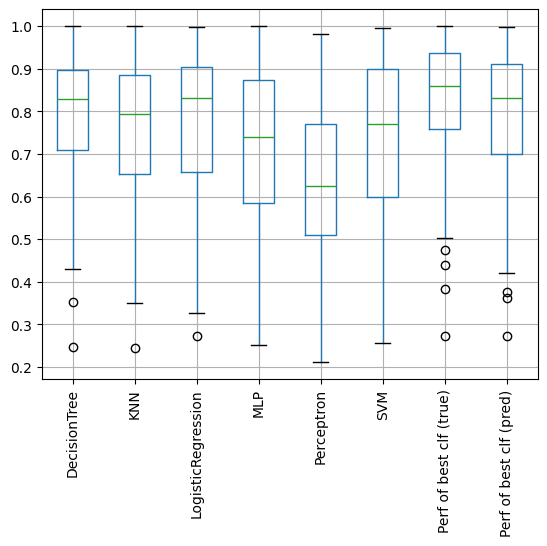

In [ ]:
final_summary.boxplot(rot=90)

# Seleção de meta-features

## Algoritmo Genético:

In [ ]:
import numpy as np
import pandas as pd
import warnings
import threading
import matplotlib.pyplot as plt

from dataclasses import dataclass
from joblib import Parallel, delayed

from sklearn.base import clone
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.feature_selection import mutual_info_classif
from sklearn.impute import SimpleImputer
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

In [ ]:
@dataclass(frozen=True)
class GAConfig:
    name: str = "AG"
    target_col: str = "Best"
    population_size: int = 40
    generations: int = 60
    elitism: int = 4
    tournament_size: int = 4
    crossover_rate: float = 0.85
    mutation_start: float = 0.08
    mutation_end: float = 0.015
    init_min_prob: float = 0.05
    init_max_prob: float = 0.30
    parsimony_weight: float = 0.08
    parsimony_power: float = 1.25
    stability_weight: float = 0.10
    cv_splits: int = 5
    scoring: str = "f1_weighted"
    patience: int = 15
    immigrant_rate: float = 0.12
    local_search_rounds: int = 4
    local_search_add_candidates: int = 25
    min_samples_per_class: int = 2
    hard_max_features: int | None = None
    initialization_strategy: str = "guided"
    crossover_mode: str = "uniform"
    mutation_mode: str = "remove_bias"
    use_local_search: bool = True
    sparse_target_ratio: float = 0.12
    n_jobs: int = -1
    random_state: int = 42


@dataclass(frozen=True)
class Score:
    fitness: float
    f1_mean: float
    f1_std: float
    n_features: int


@dataclass
class GAResult:
    name: str
    selected_features: list
    selected_mask: np.ndarray
    fitness: float
    f1_mean: float
    f1_std: float
    n_features: int
    history: pd.DataFrame
    model: object | None = None
    last_error: object | None = None
    config: GAConfig | None = None

In [ ]:
classifier_cols = [c for c in meta_dataset.columns if c in ['DecisionTree', 'SVM', 'KNN',
                                                           'LogisticRegression', 'Perceptron', 'MLP']]
meta_feature_cols = [c for c in meta_dataset.columns if c not in ['Dataset', 'Best'] + classifier_cols]

In [ ]:
base_config = GAConfig()

feature_cols = list(meta_feature_cols)

missing_features = [col for col in feature_cols if col not in meta_dataset.columns]

if missing_features:
    raise ValueError(f"As seguintes features não existem em meta_dataset: {missing_features}")

if base_config.target_col not in meta_dataset.columns:
    raise ValueError(f"A coluna alvo '{base_config.target_col}' não existe em meta_dataset.")

target_raw = meta_dataset[base_config.target_col].copy()

valid_target_mask = target_raw.notna()
dataset_ga = meta_dataset.loc[valid_target_mask].copy()
target_raw = dataset_ga[base_config.target_col].copy()

class_counts_before = target_raw.value_counts()

valid_classes = class_counts_before[
    class_counts_before >= base_config.min_samples_per_class
].index

rare_classes = class_counts_before[
    class_counts_before < base_config.min_samples_per_class
]

if len(rare_classes) > 0:
    print("Classes removidas por terem poucas amostras:")
    print(rare_classes)
    print("-" * 90)

dataset_ga = dataset_ga[
    dataset_ga[base_config.target_col].isin(valid_classes)
].copy()

X_df = dataset_ga[feature_cols].reset_index(drop=True)
y = dataset_ga[base_config.target_col].reset_index(drop=True)

import hashlib


@dataclass(frozen=True)
class FeatureFilterConfig:
    missing_threshold: float = 0.60
    quasi_constant_threshold: float = 0.98
    correlation_threshold: float = 0.985
    use_correlation_filter: bool = True


filter_config = FeatureFilterConfig(
    missing_threshold=0.60,
    quasi_constant_threshold=0.98,
    correlation_threshold=0.985,
    use_correlation_filter=True
)


def column_fingerprint(series):
    values = series.astype("string").fillna("__missing__")
    hashes = pd.util.hash_pandas_object(values, index=False).to_numpy(dtype=np.uint64)
    return hashlib.blake2b(hashes.tobytes(), digest_size=16).hexdigest()


def filter_features_unsupervised(X_df, config):
    X = X_df.copy()
    report = []

    initial_features = X.shape[1]

    missing_ratio = X.isna().mean()
    cols_high_missing = missing_ratio[missing_ratio > config.missing_threshold].index.tolist()
    X = X.drop(columns=cols_high_missing)

    report.append({
        "etapa": "Muitos valores ausentes",
        "removidas": len(cols_high_missing),
        "restantes": X.shape[1]
    })

    nunique = X.nunique(dropna=True)
    cols_constant = nunique[nunique <= 1].index.tolist()
    X = X.drop(columns=cols_constant)

    report.append({
        "etapa": "Constantes",
        "removidas": len(cols_constant),
        "restantes": X.shape[1]
    })

    cols_quasi_constant = []

    for col in X.columns:
        freq = X[col].value_counts(dropna=False, normalize=True)

        if len(freq) > 0 and freq.iloc[0] >= config.quasi_constant_threshold:
            cols_quasi_constant.append(col)

    X = X.drop(columns=cols_quasi_constant)

    report.append({
        "etapa": "Quase constantes",
        "removidas": len(cols_quasi_constant),
        "restantes": X.shape[1]
    })

    seen = {}
    cols_duplicate = []

    for col in X.columns:
        fp = column_fingerprint(X[col])

        if fp in seen:
            base_col = seen[fp]

            s1 = X[col].astype("string").fillna("__missing__")
            s2 = X[base_col].astype("string").fillna("__missing__")

            if s1.equals(s2):
                cols_duplicate.append(col)
        else:
            seen[fp] = col

    X = X.drop(columns=cols_duplicate)

    report.append({
        "etapa": "Duplicadas",
        "removidas": len(cols_duplicate),
        "restantes": X.shape[1]
    })

    cols_correlated = []

    if config.use_correlation_filter:
        numeric_cols = X.select_dtypes(include=np.number).columns.tolist()

        if len(numeric_cols) > 1:
            X_num = X[numeric_cols].copy()
            X_num = X_num.apply(pd.to_numeric, errors="coerce")
            X_num = X_num.fillna(X_num.median(numeric_only=True))
            X_num = X_num.fillna(0)

            corr = X_num.corr().abs()
            upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

            cols_correlated = [
                col for col in upper.columns
                if any(upper[col] > config.correlation_threshold)
            ]

            X = X.drop(columns=cols_correlated)

    report.append({
        "etapa": "Alta correlação numérica",
        "removidas": len(cols_correlated),
        "restantes": X.shape[1]
    })

    report_df = pd.DataFrame(report)

    removed_features = list(set(X_df.columns) - set(X.columns))

    summary = {
        "features_iniciais": initial_features,
        "features_finais": X.shape[1],
        "features_removidas": len(removed_features),
        "removed_features": removed_features,
        "report": report_df
    }

    return X, summary


X_df, filter_summary = filter_features_unsupervised(
    X_df=X_df,
    config=filter_config
)

feature_cols = list(X_df.columns)
n_total_features = len(feature_cols)

print("Resumo da filtragem inicial:")
print(filter_summary["report"])
print("-" * 90)
print(f"Features antes: {filter_summary['features_iniciais']}")
print(f"Features depois: {filter_summary['features_finais']}")
print(f"Features removidas: {filter_summary['features_removidas']}")

class_counts = y.value_counts()

if y.nunique() < 2:
    raise ValueError(
        "Após remover classes raras, sobrou apenas uma classe em 'Best'. "
        "Não é possível treinar um classificador supervisionado."
    )

min_class_count = int(class_counts.min())
cv_splits = min(base_config.cv_splits, min_class_count)

if cv_splits < 2:
    raise ValueError(
        "Não há amostras suficientes para validação cruzada. "
        "Você precisa de pelo menos 2 amostras por classe."
    )

n_total_features = len(feature_cols)

cv = StratifiedKFold(
    n_splits=cv_splits,
    shuffle=True,
    random_state=base_config.random_state
)

print("Distribuição original das classes:")
print(class_counts_before)

print("\nDistribuição usada no AG:")
print(class_counts)

print(f"\nCV ajustado para {cv_splits} folds.")
print(f"Features totais: {n_total_features}")
print(f"Amostras usadas: {len(X_df)}")
print("-" * 90)

Classes removidas por terem poucas amostras:
Best
Perceptron    1
Name: count, dtype: int64
------------------------------------------------------------------------------------------


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Resumo da filtragem inicial:
                      etapa  removidas  restantes
0   Muitos valores ausentes         10       1375
1                Constantes         36       1339
2          Quase constantes         13       1326
3                Duplicadas        190       1136
4  Alta correlação numérica        146        990
------------------------------------------------------------------------------------------
Features antes: 1385
Features depois: 990
Features removidas: 395
Distribuição original das classes:
Best
LogisticRegression    39
DecisionTree          22
SVM                   14
MLP                   10
KNN                    8
Perceptron             1
Name: count, dtype: int64

Distribuição usada no AG:
Best
LogisticRegression    39
DecisionTree          22
SVM                   14
MLP                   10
KNN                    8
Name: count, dtype: int64

CV ajustado para 5 folds.
Features totais: 990
Amostras usadas: 93
-----------------------------------------------

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
base_estimator = ExtraTreesClassifier(
    n_estimators=180,
    max_features="sqrt",
    class_weight="balanced",
    random_state=base_config.random_state,
    n_jobs=1
)


def build_pipeline():
    numeric_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median"))
    ])

    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_pipeline, make_column_selector(dtype_include=np.number)),
            ("cat", categorical_pipeline, make_column_selector(dtype_exclude=np.number))
        ],
        remainder="drop"
    )

    return Pipeline([
        ("preprocessor", preprocessor),
        ("model", clone(base_estimator))
    ])

In [ ]:
def compute_feature_ranking(X_df, y, feature_cols, random_state=42):
    rng = np.random.default_rng(random_state)
    scores = np.zeros(len(feature_cols), dtype=float)

    for i, col in enumerate(feature_cols):
        s = X_df[col]

        try:
            if pd.api.types.is_numeric_dtype(s):
                s_num = pd.to_numeric(s, errors="coerce")
                median_value = s_num.median()

                if pd.isna(median_value):
                    median_value = 0.0

                arr = s_num.fillna(median_value).to_numpy().reshape(-1, 1)
                discrete = False
            else:
                arr = (
                    s.astype("string")
                    .fillna("__missing__")
                    .astype("category")
                    .cat.codes
                    .to_numpy()
                    .reshape(-1, 1)
                )
                discrete = True

            score = mutual_info_classif(
                arr,
                y,
                discrete_features=discrete,
                random_state=random_state
            )[0]

            scores[i] = 0.0 if np.isnan(score) else score

        except Exception:
            scores[i] = 0.0

    ranking = np.argsort(scores)[::-1]

    if np.all(scores == 0):
        ranking = rng.permutation(len(feature_cols))

    ranking_df = pd.DataFrame({
        "feature": feature_cols,
        "filter_score": scores
    }).sort_values("filter_score", ascending=False)

    return ranking, scores, ranking_df


feature_ranking, feature_filter_scores, feature_ranking_df = compute_feature_ranking(
    X_df=X_df,
    y=y,
    feature_cols=feature_cols,
    random_state=base_config.random_state
)

feature_ranking_df.head(20)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,feature,filter_score
895,tree_shape.quantiles.1,0.300933
570,median.histogram.9,0.291926
580,min.histogram.9,0.260290
896,tree_shape.quantiles.3,0.252680
878,tree_imbalance.min,0.246068
314,h_mean.histogram.9,0.244655
548,max.quantiles.1,0.229725
80,class_conc.histogram.0,0.229394
915,var.histogram.0,0.226910
955,wg_dist.max,0.217015


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
use_supervised_prefilter = True

supervised_top_k = min(150, n_total_features)

if use_supervised_prefilter:
    selected_prefilter_features = (
        feature_ranking_df
        .head(supervised_top_k)["feature"]
        .tolist()
    )

    X_df = X_df[selected_prefilter_features].copy()
    feature_cols = list(X_df.columns)
    n_total_features = len(feature_cols)

    feature_ranking, feature_filter_scores, feature_ranking_df = compute_feature_ranking(
        X_df=X_df,
        y=y,
        feature_cols=feature_cols,
        random_state=base_config.random_state
    )

    print(f"Filtro supervisionado aplicado.")
    print(f"Top-k usado: {supervised_top_k}")
    print(f"Features restantes: {n_total_features}")
else:
    print("Filtro supervisionado não aplicado.")

Filtro supervisionado aplicado.
Top-k usado: 150
Features restantes: 150


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
class GeneticFeatureSelector:
    def __init__(
        self,
        X_df,
        y,
        feature_cols,
        feature_ranking,
        pipeline_factory,
        cv,
        config
    ):
        self.X_df = X_df
        self.y = y
        self.feature_cols = list(feature_cols)
        self.feature_ranking = np.asarray(feature_ranking)
        self.pipeline_factory = pipeline_factory
        self.cv = cv
        self.config = config
        self.rng = np.random.default_rng(config.random_state)
        self.n_total_features = len(feature_cols)
        self.fitness_cache = {}
        self.cache_lock = threading.Lock()
        self.last_error = None

        self.rank_position = np.empty(self.n_total_features, dtype=int)
        self.rank_position[self.feature_ranking] = np.arange(self.n_total_features)

    def individual_key(self, individual):
        return np.packbits(individual.astype(np.uint8)).tobytes()

    def repair(self, individual):
        individual = individual.astype(np.uint8, copy=True)

        if individual.sum() == 0:
            individual[self.feature_ranking[0]] = 1

        if self.config.hard_max_features is not None and individual.sum() > self.config.hard_max_features:
            selected = np.flatnonzero(individual)
            selected_sorted = selected[np.argsort(self.rank_position[selected])]
            keep = selected_sorted[:self.config.hard_max_features]
            individual[:] = 0
            individual[keep] = 1

        return individual

    def evaluate_individual(self, individual):
        individual = self.repair(individual)
        key = self.individual_key(individual)

        with self.cache_lock:
            cached = self.fitness_cache.get(key)

        if cached is not None:
            return cached

        selected_idx = np.flatnonzero(individual)
        n_features = len(selected_idx)

        if n_features == 0:
            score = Score(-1e9, 0.0, 0.0, 0)

            with self.cache_lock:
                self.fitness_cache[key] = score

            return score

        selected_cols = [self.feature_cols[i] for i in selected_idx]
        X_subset = self.X_df[selected_cols]

        try:
            model = self.pipeline_factory()

            with warnings.catch_warnings():
                warnings.simplefilter("ignore")

                fold_scores = cross_val_score(
                    model,
                    X_subset,
                    self.y,
                    cv=self.cv,
                    scoring=self.config.scoring,
                    n_jobs=1,
                    error_score=0.0
                )

            f1_mean = float(np.mean(fold_scores))
            f1_std = float(np.std(fold_scores))

            size_ratio = n_features / self.n_total_features
            size_penalty = self.config.parsimony_weight * (size_ratio ** self.config.parsimony_power)
            stability_penalty = self.config.stability_weight * f1_std

            fitness_value = f1_mean - size_penalty - stability_penalty

            score = Score(
                fitness=fitness_value,
                f1_mean=f1_mean,
                f1_std=f1_std,
                n_features=n_features
            )

        except Exception as exc:
            self.last_error = exc

            score = Score(
                fitness=-1e9,
                f1_mean=0.0,
                f1_std=0.0,
                n_features=n_features
            )

        with self.cache_lock:
            self.fitness_cache[key] = score

        return score

    def evaluate_population(self, population):
        return Parallel(
            n_jobs=self.config.n_jobs,
            prefer="threads"
        )(
            delayed(self.evaluate_individual)(ind) for ind in population
        )

    def random_individual(self):
        prob = self.rng.uniform(self.config.init_min_prob, self.config.init_max_prob)
        individual = (self.rng.random(self.n_total_features) < prob).astype(np.uint8)
        return self.repair(individual)

    def top_k_individual(self, k):
        individual = np.zeros(self.n_total_features, dtype=np.uint8)
        k = max(1, min(k, self.n_total_features))
        individual[self.feature_ranking[:k]] = 1
        return self.repair(individual)

    def initialize_population(self):
        population = []
        seen = set()

        if self.config.initialization_strategy in ["guided", "mixed"]:
            seed_sizes = [
                1,
                2,
                3,
                5,
                8,
                13,
                max(1, self.n_total_features // 20),
                max(1, self.n_total_features // 10),
                max(1, self.n_total_features // 5)
            ]

            for k in seed_sizes:
                ind = self.top_k_individual(k)
                key = self.individual_key(ind)

                if key not in seen:
                    population.append(ind)
                    seen.add(key)

        attempts = 0
        max_attempts = self.config.population_size * 200

        while len(population) < self.config.population_size and attempts < max_attempts:
            ind = self.random_individual()
            key = self.individual_key(ind)

            if key not in seen:
                population.append(ind)
                seen.add(key)

            attempts += 1

        while len(population) < self.config.population_size:
            population.append(self.random_individual())

        return population[:self.config.population_size]

    def tournament_select(self, population, scores):
        candidates = self.rng.choice(
            len(population),
            size=min(self.config.tournament_size, len(population)),
            replace=False
        )

        best_idx = max(
            candidates,
            key=lambda idx: (
                scores[idx].fitness,
                scores[idx].f1_mean,
                -scores[idx].n_features
            )
        )

        return population[best_idx].copy()

    def crossover(self, parent1, parent2):
        if self.rng.random() > self.config.crossover_rate:
            return parent1.copy(), parent2.copy()

        if self.config.crossover_mode == "one_point" and self.n_total_features > 1:
            point = self.rng.integers(1, self.n_total_features)

            child1 = np.concatenate([parent1[:point], parent2[point:]]).astype(np.uint8)
            child2 = np.concatenate([parent2[:point], parent1[point:]]).astype(np.uint8)

        else:
            mask = self.rng.random(self.n_total_features) < 0.5

            child1 = np.where(mask, parent1, parent2).astype(np.uint8)
            child2 = np.where(mask, parent2, parent1).astype(np.uint8)

        return self.repair(child1), self.repair(child2)

    def mutate(self, individual, generation):
        progress = generation / max(1, self.config.generations - 1)
        mutation_prob = self.config.mutation_start * (1.0 - progress) + self.config.mutation_end * progress

        individual = individual.copy()

        if self.config.mutation_mode == "flip":
            flip_mask = self.rng.random(self.n_total_features) < mutation_prob
            individual[flip_mask] = 1 - individual[flip_mask]

        elif self.config.mutation_mode == "sparse_adaptive":
            selected = individual == 1
            not_selected = individual == 0

            target_features = self.config.hard_max_features

            if target_features is None:
                target_features = max(1, int(self.n_total_features * self.config.sparse_target_ratio))

            current_features = int(individual.sum())

            if current_features > target_features:
                remove_factor = 2.00
                add_factor = 0.30
            else:
                remove_factor = 1.10
                add_factor = 0.70

            remove_mask = selected & (self.rng.random(self.n_total_features) < mutation_prob * remove_factor)
            add_mask = not_selected & (self.rng.random(self.n_total_features) < mutation_prob * add_factor)

            individual[remove_mask] = 0
            individual[add_mask] = 1

        else:
            selected = individual == 1
            not_selected = individual == 0

            remove_mask = selected & (self.rng.random(self.n_total_features) < mutation_prob * 1.25)
            add_mask = not_selected & (self.rng.random(self.n_total_features) < mutation_prob * 0.65)

            individual[remove_mask] = 0
            individual[add_mask] = 1

        return self.repair(individual)

    def is_better(self, new_score, old_score, eps=1e-8):
        if new_score.fitness > old_score.fitness + eps:
            return True

        if abs(new_score.fitness - old_score.fitness) <= eps:
            if new_score.f1_mean > old_score.f1_mean + eps:
                return True

            if abs(new_score.f1_mean - old_score.f1_mean) <= eps:
                return new_score.n_features < old_score.n_features

        return False

    def local_search(self, best_individual, best_score):
        current = best_individual.copy()
        current_score = best_score

        for _ in range(self.config.local_search_rounds):
            candidates = []
            selected = np.flatnonzero(current)

            if len(selected) > 1:
                for idx in selected:
                    candidate = current.copy()
                    candidate[idx] = 0
                    candidates.append(self.repair(candidate))

            add_pool = [idx for idx in self.feature_ranking if current[idx] == 0]
            add_pool = add_pool[:self.config.local_search_add_candidates]

            for idx in add_pool:
                candidate = current.copy()
                candidate[idx] = 1
                candidates.append(self.repair(candidate))

            if not candidates:
                break

            candidate_scores = self.evaluate_population(candidates)

            best_candidate_idx = max(
                range(len(candidates)),
                key=lambda i: (
                    candidate_scores[i].fitness,
                    candidate_scores[i].f1_mean,
                    -candidate_scores[i].n_features
                )
            )

            candidate = candidates[best_candidate_idx]
            candidate_score = candidate_scores[best_candidate_idx]

            if self.is_better(candidate_score, current_score):
                current = candidate
                current_score = candidate_score
            else:
                break

        return current, current_score

    def fit(self, verbose=True):
        population = self.initialize_population()
        scores = self.evaluate_population(population)

        history = []

        best_global = None
        best_global_score = Score(-1e9, 0.0, 0.0, 0)
        no_improvement = 0

        if verbose:
            print("=" * 90)
            print(self.config.name)
            print("=" * 90)
            print(f"População: {self.config.population_size}")
            print(f"Gerações máximas: {self.config.generations}")
            print(f"Scoring: {self.config.scoring}")
            print(f"Inicialização: {self.config.initialization_strategy}")
            print(f"Crossover: {self.config.crossover_mode}")
            print(f"Mutação: {self.config.mutation_mode}")
            print(f"Busca local: {self.config.use_local_search}")
            print("-" * 90)

        for gen in range(self.config.generations):
            ranked_idx = sorted(
                range(len(population)),
                key=lambda i: (
                    scores[i].fitness,
                    scores[i].f1_mean,
                    -scores[i].n_features
                ),
                reverse=True
            )

            current_best = population[ranked_idx[0]].copy()
            current_score = scores[ranked_idx[0]]

            if self.is_better(current_score, best_global_score):
                best_global = current_best.copy()
                best_global_score = current_score
                no_improvement = 0
            else:
                no_improvement += 1

            history.append({
                "generation": gen,
                "fitness": best_global_score.fitness,
                "f1_mean": best_global_score.f1_mean,
                "f1_std": best_global_score.f1_std,
                "n_features": best_global_score.n_features,
                "cache_size": len(self.fitness_cache)
            })

            if verbose:
                print(
                    f"Geração {gen:03d} | "
                    f"F1: {best_global_score.f1_mean:.5f} ± {best_global_score.f1_std:.5f} | "
                    f"Features: {best_global_score.n_features}/{self.n_total_features} | "
                    f"Fitness: {best_global_score.fitness:.5f} | "
                    f"Sem melhora: {no_improvement}/{self.config.patience}"
                )

            if no_improvement >= self.config.patience:
                if verbose:
                    print("-" * 90)
                    print(f"Early stopping ativado na geração {gen}.")

                break

            new_population = [population[i].copy() for i in ranked_idx[:self.config.elitism]]

            immigrant_count = max(1, int(self.config.population_size * self.config.immigrant_rate))
            child_limit = self.config.population_size - immigrant_count

            while len(new_population) < child_limit:
                parent1 = self.tournament_select(population, scores)
                parent2 = self.tournament_select(population, scores)

                child1, child2 = self.crossover(parent1, parent2)

                child1 = self.mutate(child1, gen)
                child2 = self.mutate(child2, gen)

                new_population.append(child1)

                if len(new_population) < child_limit:
                    new_population.append(child2)

            while len(new_population) < self.config.population_size:
                new_population.append(self.random_individual())

            population = new_population[:self.config.population_size]
            scores = self.evaluate_population(population)

        if self.config.use_local_search:
            if verbose:
                print("-" * 90)
                print("Aplicando busca local final...")

            best_global, best_global_score = self.local_search(best_global, best_global_score)

        selected_idx = np.flatnonzero(best_global)
        final_features = [self.feature_cols[i] for i in selected_idx]

        if verbose:
            print("-" * 90)
            print("RESULTADO FINAL")
            print(f"Features selecionadas: {best_global_score.n_features}/{self.n_total_features}")
            print(f"F1 estimado: {best_global_score.f1_mean:.5f} ± {best_global_score.f1_std:.5f}")
            print(f"Fitness final: {best_global_score.fitness:.5f}")
            print("Atributos selecionados:")
            print(final_features)

            if self.last_error is not None and best_global_score.f1_mean == 0.0:
                print("Último erro capturado durante avaliação:")
                print(repr(self.last_error))

        return GAResult(
            name=self.config.name,
            selected_features=final_features,
            selected_mask=best_global,
            fitness=best_global_score.fitness,
            f1_mean=best_global_score.f1_mean,
            f1_std=best_global_score.f1_std,
            n_features=best_global_score.n_features,
            history=pd.DataFrame(history),
            last_error=self.last_error,
            config=self.config
        )

In [ ]:
hard_max_features_compact = max(
    1,
    min(
        n_total_features,
        max(5, n_total_features // 8)
    )
)

ga_configs = [
    GAConfig(
        name="AG 1 - Clássico binário",
        target_col=base_config.target_col,
        population_size=80,
        generations=150,
        elitism=4,
        tournament_size=4,
        crossover_rate=0.85,
        mutation_start=0.10,
        mutation_end=0.02,
        init_min_prob=0.08,
        init_max_prob=0.40,
        parsimony_weight=0.04,
        parsimony_power=1.10,
        stability_weight=0.05,
        cv_splits=cv_splits,
        scoring="f1_weighted",
        patience=25,
        immigrant_rate=0.08,
        hard_max_features=None,
        initialization_strategy="random",
        crossover_mode="one_point",
        mutation_mode="flip",
        use_local_search=False,
        n_jobs=-1,
        random_state=42
    ),

    GAConfig(
        name="AG 2 - Guiado por MI + busca local",
        target_col=base_config.target_col,
        population_size=80,
        generations=150,
        elitism=4,
        tournament_size=4,
        crossover_rate=0.85,
        mutation_start=0.08,
        mutation_end=0.015,
        init_min_prob=0.05,
        init_max_prob=0.30,
        parsimony_weight=0.08,
        parsimony_power=1.25,
        stability_weight=0.10,
        cv_splits=cv_splits,
        scoring="f1_weighted",
        patience=25,
        immigrant_rate=0.12,
        local_search_rounds=4,
        local_search_add_candidates=25,
        hard_max_features=None,
        initialization_strategy="guided",
        crossover_mode="uniform",
        mutation_mode="remove_bias",
        use_local_search=True,
        n_jobs=-1,
        random_state=42
    ),

    GAConfig(
        name="AG 3 - Compacto/esparso",
        target_col=base_config.target_col,
        population_size=80,
        generations=150,
        elitism=5,
        tournament_size=5,
        crossover_rate=0.90,
        mutation_start=0.10,
        mutation_end=0.01,
        init_min_prob=0.03,
        init_max_prob=0.18,
        parsimony_weight=0.16,
        parsimony_power=1.50,
        stability_weight=0.12,
        cv_splits=cv_splits,
        scoring="f1_weighted",
        patience=25,
        immigrant_rate=0.15,
        local_search_rounds=5,
        local_search_add_candidates=30,
        hard_max_features=hard_max_features_compact,
        initialization_strategy="guided",
        crossover_mode="uniform",
        mutation_mode="sparse_adaptive",
        use_local_search=True,
        sparse_target_ratio=0.10,
        n_jobs=-1,
        random_state=42
    )
]

In [ ]:
results = []

for cfg in ga_configs:
    selector = GeneticFeatureSelector(
        X_df=X_df,
        y=y,
        feature_cols=feature_cols,
        feature_ranking=feature_ranking,
        pipeline_factory=build_pipeline,
        cv=cv,
        config=cfg
    )

    result = selector.fit(verbose=True)

    final_model = build_pipeline()
    final_model.fit(X_df[result.selected_features], y)

    result.model = final_model

    results.append(result)

AG 1 - Clássico binário
População: 80
Gerações máximas: 150
Scoring: f1_weighted
Inicialização: random
Crossover: one_point
Mutação: flip
Busca local: False
------------------------------------------------------------------------------------------
Geração 000 | F1: 0.59551 ± 0.13076 | Features: 48/150 | Fitness: 0.57755 | Sem melhora: 0/25
Geração 001 | F1: 0.59551 ± 0.13076 | Features: 48/150 | Fitness: 0.57755 | Sem melhora: 1/25
Geração 002 | F1: 0.59652 ± 0.09829 | Features: 51/150 | Fitness: 0.57940 | Sem melhora: 0/25
Geração 003 | F1: 0.59652 ± 0.09829 | Features: 51/150 | Fitness: 0.57940 | Sem melhora: 1/25
Geração 004 | F1: 0.59652 ± 0.09829 | Features: 51/150 | Fitness: 0.57940 | Sem melhora: 2/25
Geração 005 | F1: 0.60969 ± 0.15035 | Features: 70/150 | Fitness: 0.58487 | Sem melhora: 0/25
Geração 006 | F1: 0.60969 ± 0.15035 | Features: 70/150 | Fitness: 0.58487 | Sem melhora: 1/25
Geração 007 | F1: 0.60969 ± 0.15035 | Features: 70/150 | Fitness: 0.58487 | Sem melhora: 2/25


In [ ]:
comparison_df = pd.DataFrame([
    {
        "metodo": result.name,
        "f1_mean": result.f1_mean,
        "f1_std": result.f1_std,
        "fitness": result.fitness,
        "n_features": result.n_features,
        "percentual_features": result.n_features / n_total_features,
        "features": result.selected_features
    }
    for result in results
]).sort_values(
    by=["f1_mean", "fitness", "n_features"],
    ascending=[False, False, True]
).reset_index(drop=True)

comparison_df

,metodo,f1_mean,f1_std,fitness,n_features,percentual_features,features
0,AG 3 - Compacto/esparso,0.696764,0.045049,0.684707,18,0.120000,"[tree_shape.quantiles.1, median.histogram.9, m..."
1,AG 2 - Guiado por MI + busca local,0.679258,0.101682,0.653760,40,0.266667,"[median.histogram.9, min.histogram.9, tree_imb..."
2,AG 1 - Clássico binário,0.641563,0.110128,0.619573,67,0.446667,"[tree_shape.quantiles.1, median.histogram.9, m..."


In [ ]:
best_result = max(
    results,
    key=lambda result: (
        result.f1_mean,
        result.fitness,
        -result.n_features
    )
)

result_ga = {
    "selected_features": best_result.selected_features,
    "selected_mask": best_result.selected_mask,
    "fitness": best_result.fitness,
    "f1_mean": best_result.f1_mean,
    "f1_std": best_result.f1_std,
    "n_features": best_result.n_features,
    "history": best_result.history,
    "model": best_result.model,
    "feature_filter_scores": feature_ranking_df,
    "class_counts_original": class_counts_before,
    "class_counts_used": class_counts,
    "comparison": comparison_df,
    "all_results": results
}

print("Melhor resultado por F1:")
print(best_result.name)
print("-" * 90)
print(f"F1 estimado: {best_result.f1_mean:.5f} ± {best_result.f1_std:.5f}")
print(f"Fitness: {best_result.fitness:.5f}")
print(f"Features selecionadas: {best_result.n_features}/{n_total_features}")
print("-" * 90)
print(best_result.selected_features)

Melhor resultado por F1:
AG 3 - Compacto/esparso
------------------------------------------------------------------------------------------
F1 estimado: 0.69676 ± 0.04505
Fitness: 0.68471
Features selecionadas: 18/150
------------------------------------------------------------------------------------------
['tree_shape.quantiles.1', 'median.histogram.9', 'min.histogram.9', 'tree_shape.quantiles.3', 'var.histogram.0', 'wg_dist.max', 'range.median', 'mad.histogram.0', 'sparsity.histogram.9', 'elite_nn.max', 'best_node.max', 'range.histogram.0', 'max.histogram.9', 'nr_attr', 'g_mean.histogram.9', 'one_nn.quantiles.1.relative', 'elite_nn.max.relative', 'min.max']


In [ ]:
for result in results:
    print("=" * 90)
    print(result.name)
    print(f"F1: {result.f1_mean:.5f} ± {result.f1_std:.5f}")
    print(f"Fitness: {result.fitness:.5f}")
    print(f"Features: {result.n_features}/{n_total_features}")
    print("-" * 90)

    for feature in result.selected_features:
        print(feature)

AG 1 - Clássico binário
F1: 0.64156 ± 0.11013
Fitness: 0.61957
Features: 67/150
------------------------------------------------------------------------------------------
tree_shape.quantiles.1
median.histogram.9
min.histogram.9
tree_shape.quantiles.3
h_mean.histogram.9
mad.histogram.0
sparsity.histogram.9
leaves_branch.quantiles.1
elite_nn.median
best_node.max
range.min
range.histogram.0
elite_nn.min
tree_depth.histogram.9
max.histogram.9
leaves_branch.sd
nr_attr
f3.mean
n2.histogram.7
mad.histogram.9
elite_nn.median.relative
tree_imbalance.quantiles.1
one_nn.quantiles.1.relative
elite_nn.max.relative
best_node.max.relative
leaves_homo.median
mean.median
impconceptvar.mean
one_nn.min
nodes_per_level.median
attr_ent.histogram.0
elite_nn.quantiles.1
mean.histogram.9
max.min
f3.min
sparsity.histogram.3
wg_dist.histogram.5
attr_ent.quantiles.1
joint_ent.histogram.0
one_nn.median.relative
random_node.histogram.9
f3.quantiles.1
leaves_branch.max
leaves_homo.min
nodes_per_inst
one_nn.mean
le

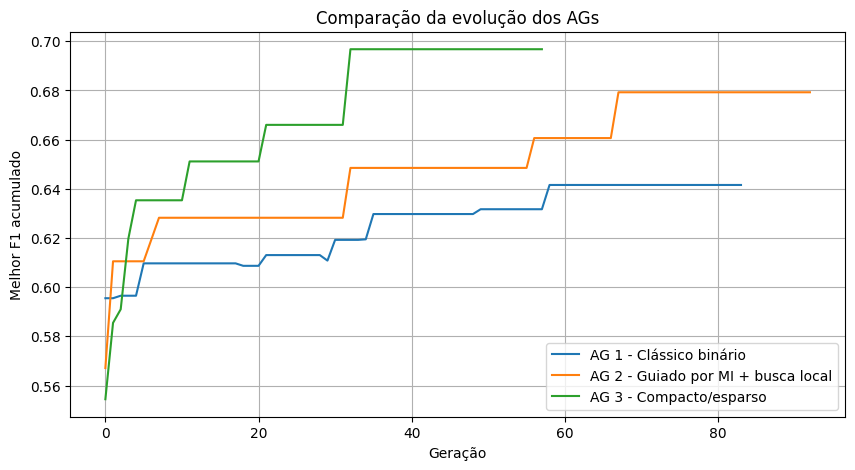

In [ ]:
plt.figure(figsize=(10, 5))

for result in results:
    plt.plot(
        result.history["generation"],
        result.history["f1_mean"],
        label=result.name
    )

plt.xlabel("Geração")
plt.ylabel("Melhor F1 acumulado")
plt.title("Comparação da evolução dos AGs")
plt.legend()
plt.grid(True)
plt.show()

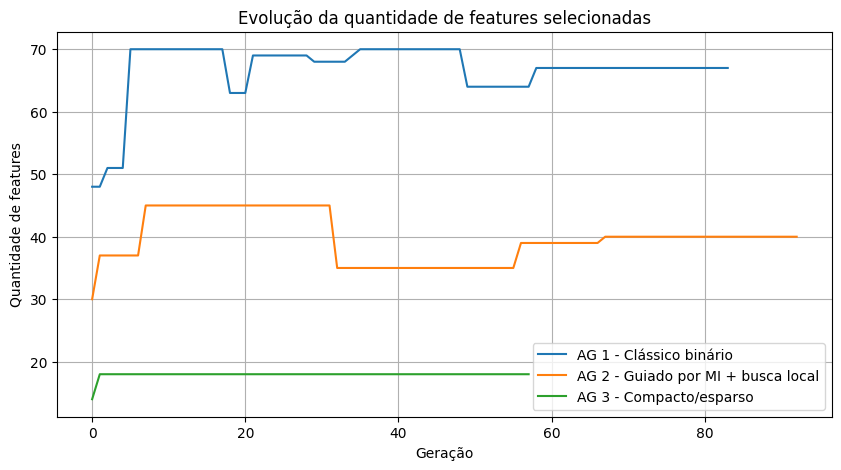

In [ ]:
plt.figure(figsize=(10, 5))

for result in results:
    plt.plot(
        result.history["generation"],
        result.history["n_features"],
        label=result.name
    )

plt.xlabel("Geração")
plt.ylabel("Quantidade de features")
plt.title("Evolução da quantidade de features selecionadas")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
comparison_df.to_csv("comparacao_algoritmos_geneticos_features.csv", index=False)

feature_ranking_df.to_csv("ranking_filtro_mutual_info.csv", index=False)

print("Arquivos exportados:")
print("comparacao_algoritmos_geneticos_features.csv")
print("ranking_filtro_mutual_info.csv")

Arquivos exportados:
comparacao_algoritmos_geneticos_features.csv
ranking_filtro_mutual_info.csv
